# 06 — Model Explainability
**FlightIQ — AI Travel Price Intelligence**

---
Feature importance (native MDI) and SHAP analysis for the best trained model.
SHAP runs on a 2,000-row subsample for speed.


In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import joblib, json
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
sys.path.insert(0, os.path.abspath('../src'))
from feature_engineering import prepare_data, load_data, ALL_FEATURES
from explainability import run_explainability, plot_native_feature_importance, run_shap_analysis
print('Imports OK')


Imports OK


## 1. Load Best Model & Data

In [2]:
pipe   = joblib.load('../models/flight_price_model.joblib')
model  = pipe.named_steps['model']
print(f'Best model type: {type(model).__name__}')

df = load_data()
X_train, X_test, y_train, y_test, preprocessor, feature_names = prepare_data(df)
print(f'Train: {X_train.shape}  Feature names: {len(feature_names)}')


Best model type: GradientBoostingRegressor


Train size : 74,466 rows × 86 features
Test size  : 18,617 rows × 86 features
Train: (74466, 86)  Feature names: 86


## 2. Native Feature Importance

  Saved → feature_importance_native.png


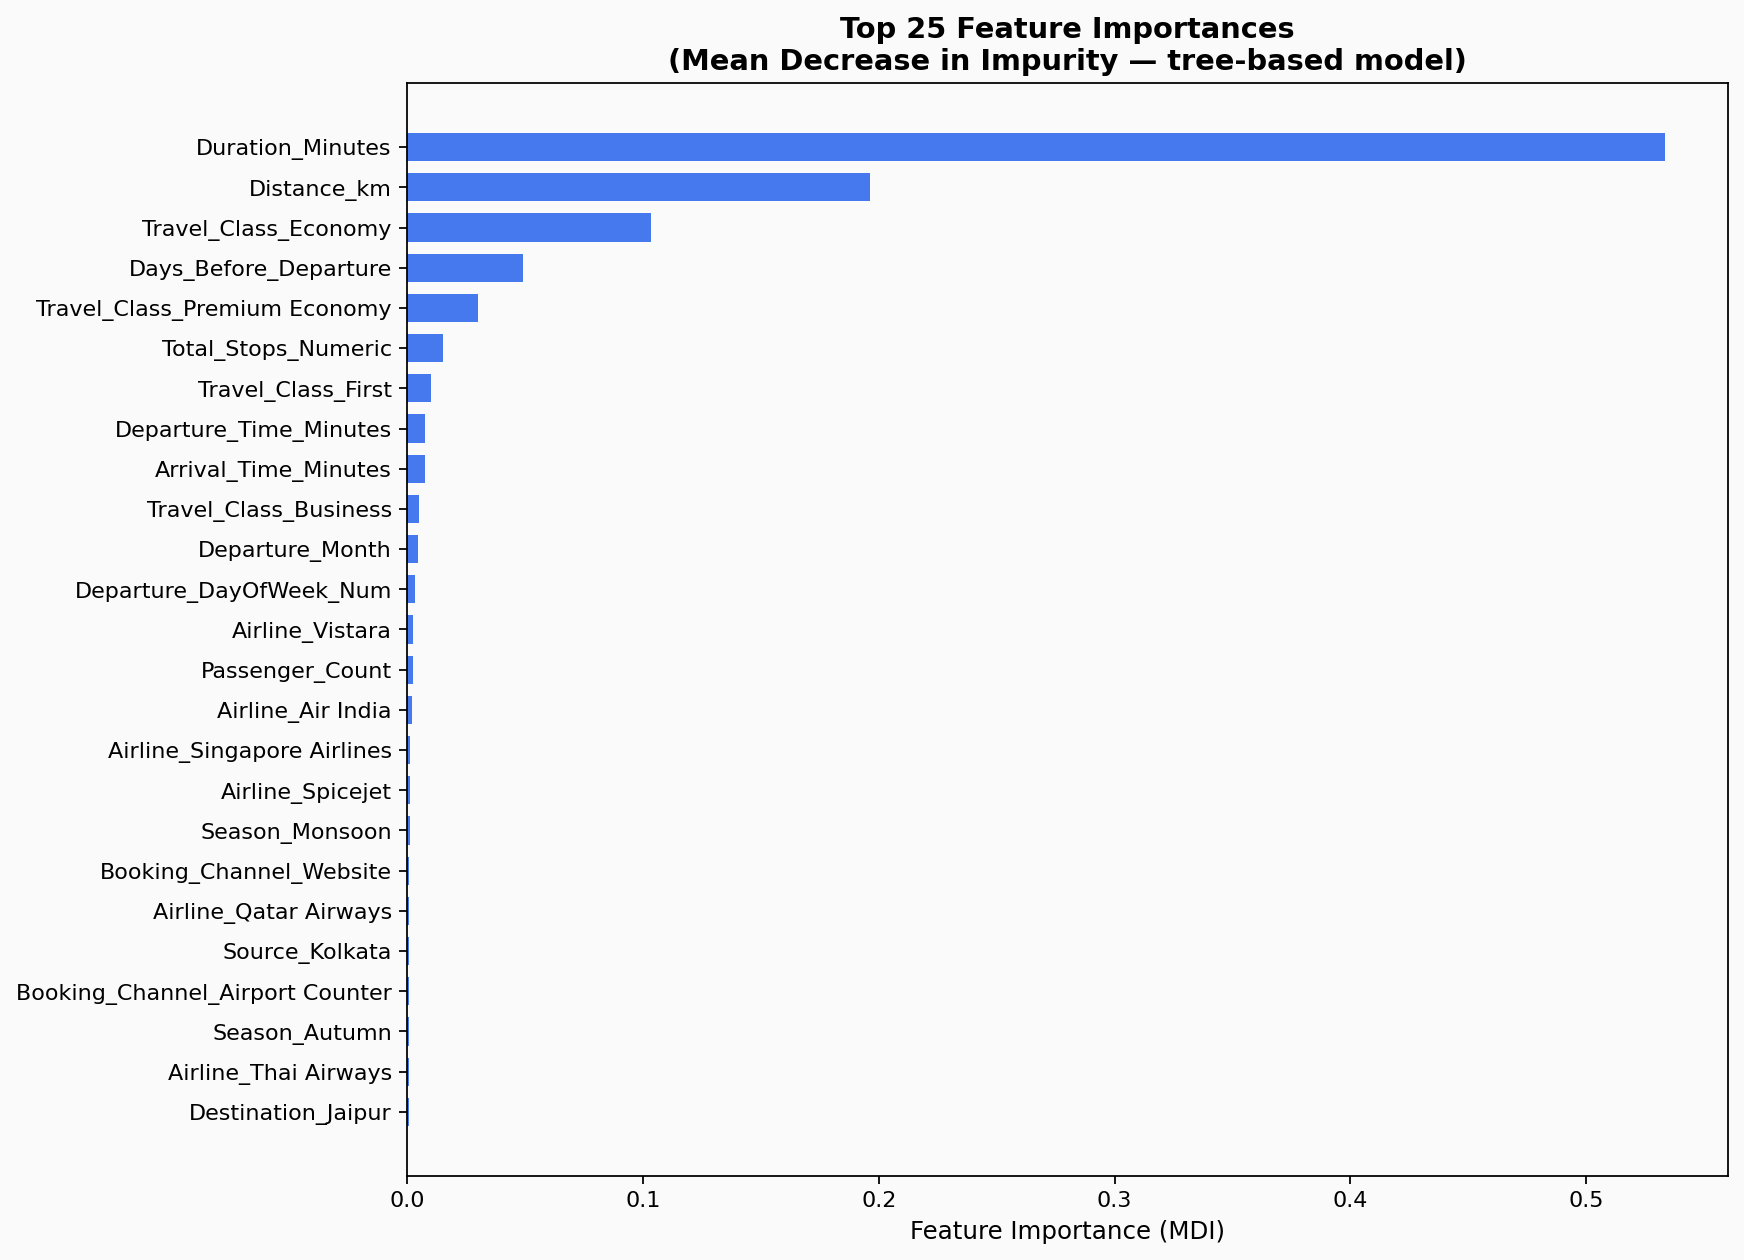

In [3]:
path = plot_native_feature_importance(model, feature_names, top_n=25)
if path:
    display(Image(filename=str(path)))


In [4]:
# Top 15 features by native importance
import numpy as np
if hasattr(model, 'feature_importances_'):
    imp = model.feature_importances_
    idx = np.argsort(imp)[::-1][:15]
    print('Top 15 features by MDI importance:')
    for rank, i in enumerate(idx, 1):
        print(f'  {rank:2}. {feature_names[i]:<45}: {imp[i]:.5f}')


Top 15 features by MDI importance:
   1. Duration_Minutes                             : 0.53360
   2. Distance_km                                  : 0.19638
   3. Travel_Class_Economy                         : 0.10334
   4. Days_Before_Departure                        : 0.04915
   5. Travel_Class_Premium Economy                 : 0.03005
   6. Total_Stops_Numeric                          : 0.01497
   7. Travel_Class_First                           : 0.01002
   8. Departure_Time_Minutes                       : 0.00765
   9. Arrival_Time_Minutes                         : 0.00749
  10. Travel_Class_Business                        : 0.00486
  11. Departure_Month                              : 0.00432
  12. Departure_DayOfWeek_Num                      : 0.00319
  13. Airline_Vistara                              : 0.00237
  14. Passenger_Count                              : 0.00232
  15. Airline_Air India                            : 0.00180


## 3. SHAP Analysis (2,000-row subsample)

  SHAP computed on 2000 samples.
  Saved → shap_summary_bar.png


  Saved → shap_beeswarm.png
Displaying: shap_beeswarm.png


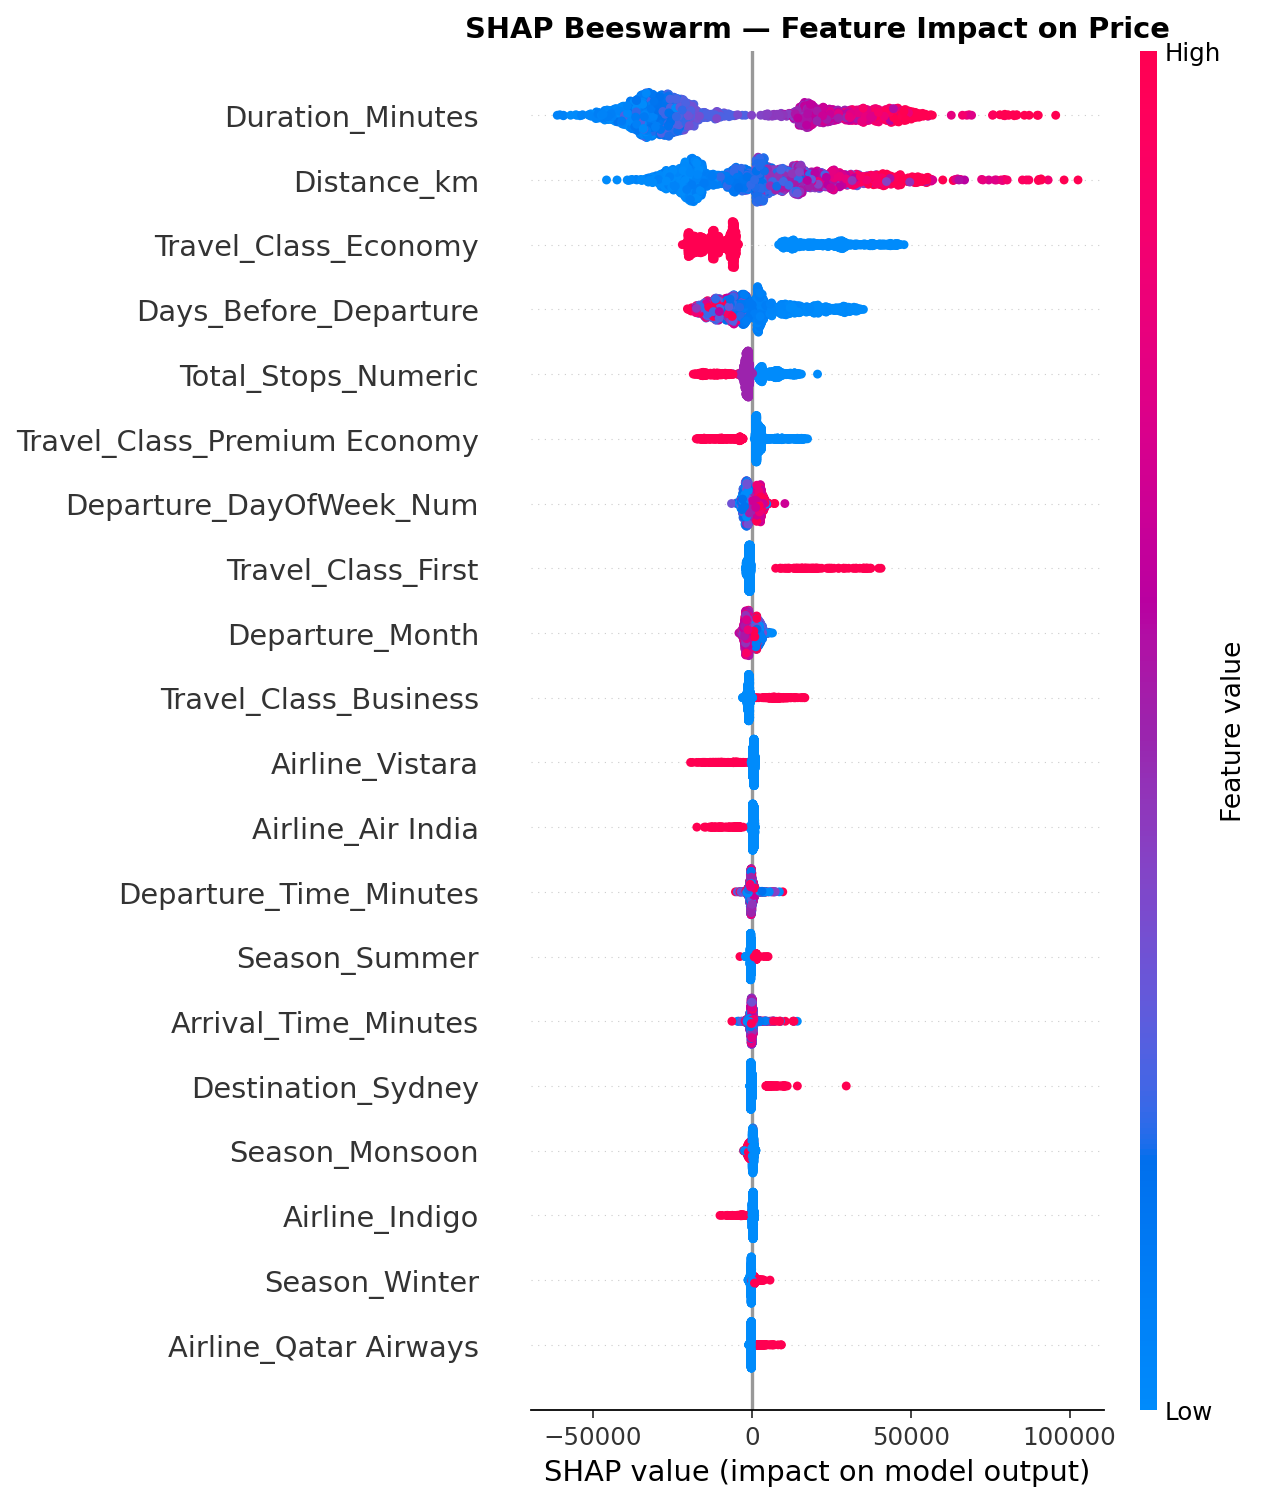

Displaying: shap_summary_bar.png


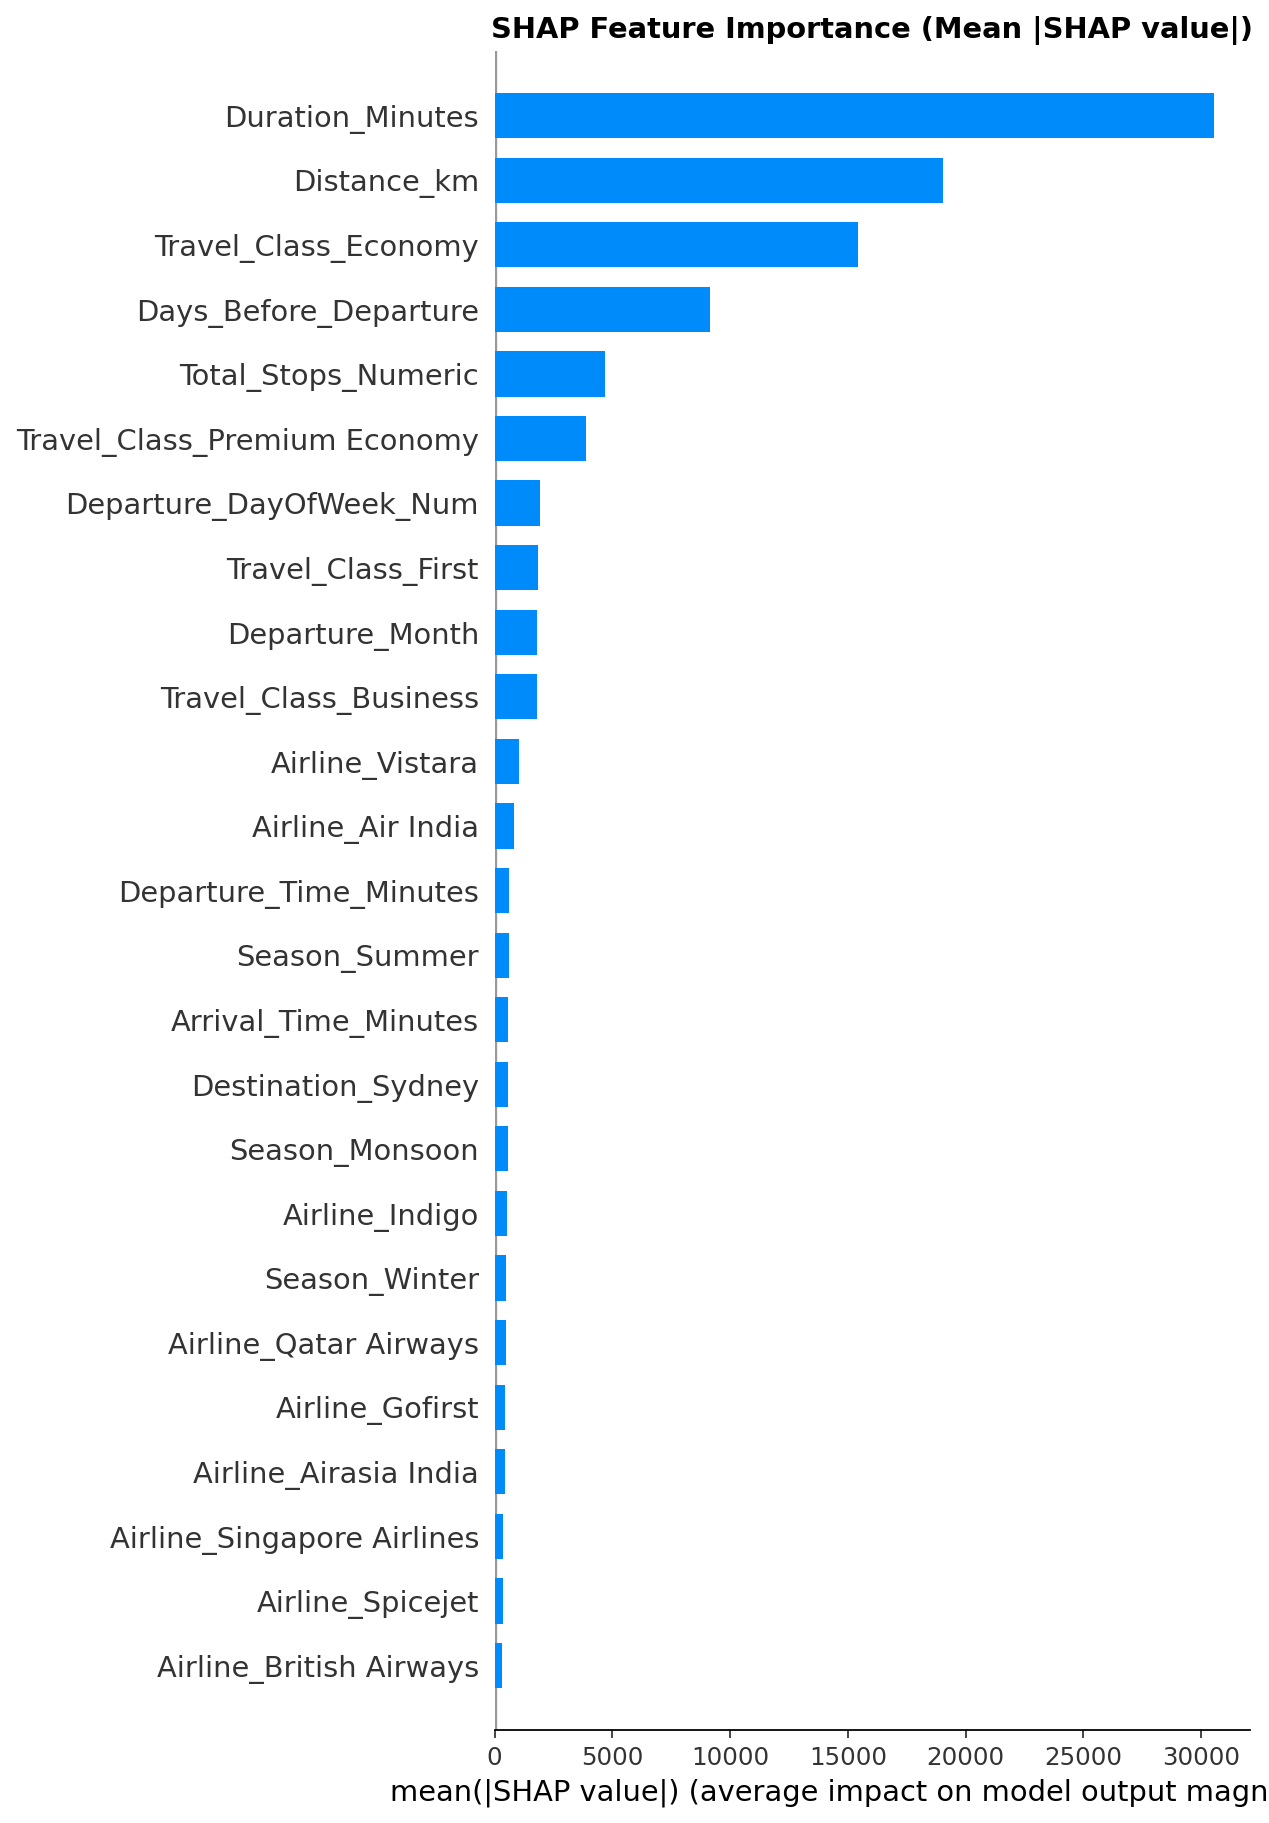

In [5]:
shap_result = run_shap_analysis(model, X_train, feature_names, sample_n=2000)

# Display SHAP plots if generated
import glob
shap_plots = sorted(glob.glob('../assets/explainability/shap_*.png'))
for p in shap_plots:
    print(f'Displaying: {os.path.basename(p)}')
    display(Image(filename=p))
if not shap_plots:
    print('SHAP plots not available — see native feature importance above.')


## 4. Interpretation Notes

In [6]:
print('INTERPRETATION NOTES:')
print('  • Feature importance scores show which features most reduce prediction error.')
print('  • This does NOT imply causation.')
print('  • Distance_km and Duration_Minutes are expected to dominate (r≈0.65 each).')
print('  • Travel_Class and Airline OHE columns should also rank highly.')
print('  • SHAP values show directional impact — positive SHAP = pushes Price higher.')
print('  • All analysis is on held-out test set to avoid overfitting bias.')


INTERPRETATION NOTES:
  • Feature importance scores show which features most reduce prediction error.
  • This does NOT imply causation.
  • Distance_km and Duration_Minutes are expected to dominate (r≈0.65 each).
  • Travel_Class and Airline OHE columns should also rank highly.
  • SHAP values show directional impact — positive SHAP = pushes Price higher.
  • All analysis is on held-out test set to avoid overfitting bias.
